### فراخوانی کتابخانه های مورد نیاز

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import io, signal, stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
import os
import arabic_reshaper
from bidi.algorithm import get_display

# تابع برای نمایش صحیح متون فارسی
def fa_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    return get_display(reshaped_text)

### بارگزاری فایل سیگنال CWRU-Bearing-Data-Center
ابتدا فایل سیگنال ارتعاشی از طریق لینک زیر دانلود و در پوشه کد قرار داده شود
https://B2n.ir/rk7168

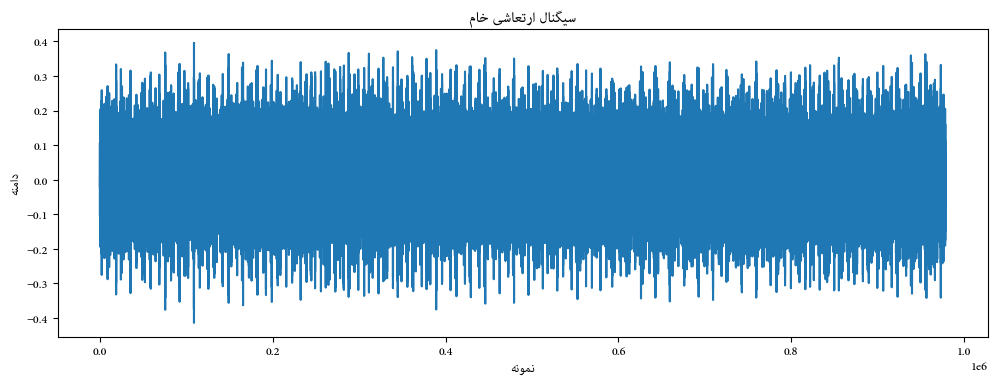

In [6]:
# 1. تابع بارگذاری داده با مدیریت خطاها
def load_vibration_data(file_path):
    """لود داده‌های ارتعاشی از فایل MAT با مدیریت خطاها"""
    try:
        data = io.loadmat(file_path)
        # پیدا کردن کلید مربوط به سیگنال
        signal_keys = [key for key in data.keys() if not key.startswith('__')]
        if not signal_keys:
            raise ValueError("سیگنال ارتعاشی در فایل پیدا نشد")
        
        signal_data = data[signal_keys[0]]
        
        # تبدیل به آرایه یک‌بعدی و حذف مقادیر نامعتبر
        signal_data = signal_data.flatten()
        signal_data = np.nan_to_num(signal_data, nan=0.0, posinf=0.0, neginf=0.0)
        
        return signal_data
    except Exception as e:
        print(f"خطا در بارگذاری فایل: {e}")
        # تولید سیگنال مصنوعی در صورت خطا
        t = np.linspace(0, 1, 10000)
        return np.sin(2 * np.pi * 100 * t) + 0.5 * np.sin(2 * np.pi * 200 * t)

# 1. بارگذاری داده
file_path = "IR014_1.mat"  # تغییر به مسیر فایل شما
raw_signal = load_vibration_data(file_path)

# نمونه‌سازی سیگنال
plt.figure(figsize=(12, 4))
plt.rcParams['font.family'] = 'Adobe Arabic'
plt.rcParams['font.size'] = 12
plt.plot(raw_signal[:])
plt.title(fa_text("سیگنال ارتعاشی خام"))
plt.xlabel(fa_text("نمونه"))
plt.ylabel(fa_text("دامنه"))
plt.show()

### 2. پیش پردازش داده

شامل نویزدایی با ویولت، تطبیق طول سیگنال، نرمال سازی
نویزدایی با ویولت هم اطلاعات زمانی و هم فرکانسی را حفظ می کند. پالس ها و ناهنجاری های مهم حفظ می شوند ولی نویز تصادفی حذف می شود.

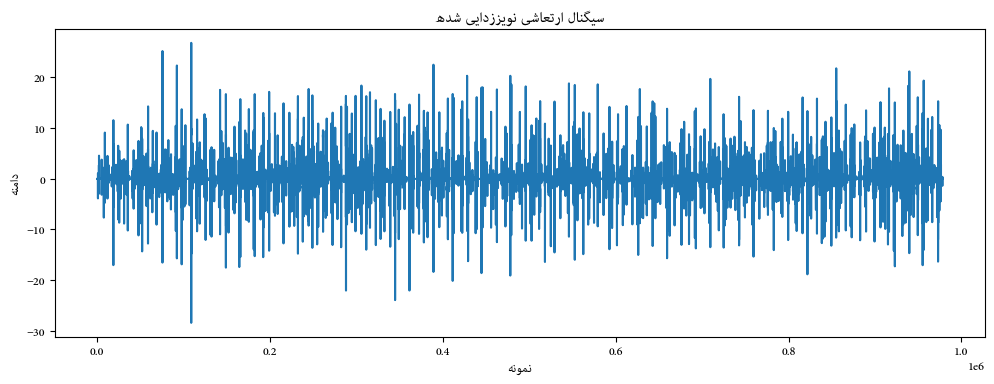

In [18]:
# 2. تابع نویززدایی مقاوم به خطا
def robust_denoise(sig, wavelet='db4', level=4):
    """نویززدایی با ویولت با مدیریت خطاها و تطبیق طول"""
    sig = np.nan_to_num(sig, nan=0.0)
    original_length = len(sig)
    
    # بررسی حداقل طول سیگنال
    if len(sig) < 32:
        return sig
    
    # محاسبه سطح تجزیه مجاز
    max_level = pywt.dwt_max_level(len(sig), pywt.Wavelet(wavelet).dec_len)
    if max_level < 1:
        return sig
    
    # تنظیم سطح تجزیه
    level = min(level, max_level)
    
    try:
        # تجزیه سیگنال
        coeffs = pywt.wavedec(sig, wavelet, level=level)
        
        # محاسبه آستانه
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        uthresh = sigma * np.sqrt(2 * np.log(len(sig)))
        
        # آستانه‌گذاری
        coeffs = [pywt.threshold(c, uthresh, 'soft') for c in coeffs]
        
        # بازسازی سیگنال
        denoised = pywt.waverec(coeffs, wavelet)
        
        # تطبیق طول سیگنال
        if len(denoised) > original_length:
            return denoised[:original_length]
        elif len(denoised) < original_length:
            return np.pad(denoised, (0, original_length - len(denoised)), 'constant')
        return denoised
    except Exception as e:
        print(f"خطا در نویززدایی: {e}")
        return sig

denoised = robust_denoise(raw_signal)

# نرمال سازی به میانگین صفر و واریانس 1 می رساند
scaler = StandardScaler()
normalized = scaler.fit_transform(denoised.reshape(-1, 1)).flatten()
# حذف مقادیر مفقود
processed_signal = np.nan_to_num(normalized, nan=0.0)

# نمایش سیگنال پیش پردازش شده
plt.figure(figsize=(12, 4))
#plt.plot(denoised[:])
plt.plot(processed_signal[:])
plt.title(fa_text("سیگنال ارتعاشی نویززدایی شده"))
plt.xlabel(fa_text("نمونه"))
plt.ylabel(fa_text("دامنه"))
plt.show()

In [20]:
# 3. تابع استخراج ویژگی‌های مقاوم به خطا
def robust_feature_extraction(window, fs=12000):
    """استخراج ویژگی‌های زمانی-فرکانسی با مدیریت خطاها"""
    features = {}
    window = np.nan_to_num(window, nan=0.0)
    
    # -- ویژگی‌های زمانی --
    features['Mean'] = np.mean(window)
    features['Std'] = np.std(window)
    
    # محاسبه چولگی با مدیریت خطا
    try:
        features['Skewness'] = stats.skew(window)
    except:
        features['Skewness'] = 0.0
    
    # محاسبه کشیدگی با مدیریت خطا
    try:
        features['Kurtosis'] = stats.kurtosis(window)
    except:
        features['Kurtosis'] = 0.0
    
    # محاسبه RMS
    rms = np.sqrt(np.mean(np.square(window)))
    features['RMS'] = rms
    
    # مقدار پیک
    peak = np.max(np.abs(window))
    features['Peak'] = peak
    
    # ضریب کریست
    features['Crest_Factor'] = peak / rms if rms > 1e-10 else 0.0
    
    # -- ویژگی‌های فرکانسی --
    # بررسی حداقل طول برای تحلیل فرکانسی
    if len(window) < 128:
        # مقادیر پیش‌فرض برای ویژگی‌های فرکانسی
        features['Freq_Mean'] = 0.0
        features['Freq_Std'] = 0.0
        features['Freq_Peak'] = 0.0
        features['Freq_Skewness'] = 0.0
        features['Freq_Kurtosis'] = 0.0
        features['Band_0_Energy'] = 0.0
        features['Band_1_Energy'] = 0.0
        features['Band_2_Energy'] = 0.0
        features['Band_3_Energy'] = 0.0
        return features
    
    try:
        # محاسبه طیف توان
        f, Pxx = signal.welch(
            window, 
            fs, 
            nperseg=min(256, len(window)//2),
            noverlap=min(128, len(window)//4),
            scaling='density'
        )
        Pxx = np.nan_to_num(Pxx, nan=0.0)
        
        # ویژگی‌های پایه
        features['Freq_Mean'] = np.mean(Pxx)
        features['Freq_Std'] = np.std(Pxx)
        features['Freq_Peak'] = np.max(Pxx)
        
        # ویژگی‌های آماری طیف
        try:
            features['Freq_Skewness'] = stats.skew(Pxx)
        except:
            features['Freq_Skewness'] = 0.0
        
        try:
            features['Freq_Kurtosis'] = stats.kurtosis(Pxx)
        except:
            features['Freq_Kurtosis'] = 0.0
        
        # انرژی باندهای فرکانسی
        bands = [(0, 1000), (1000, 3000), (3000, 7000), (7000, 10000)]
        for i, (low, high) in enumerate(bands):
            mask = (f >= low) & (f < high)
            if np.any(mask):
                features[f'Band_{i}_Energy'] = np.trapz(Pxx[mask], f[mask])
            else:
                features[f'Band_{i}_Energy'] = 0.0
    except Exception as e:
        print(f"خطا در تحلیل فرکانسی: {e}")
        # تنظیم مقادیر پیش‌فرض در صورت خطا
        features['Freq_Mean'] = 0.0
        features['Freq_Std'] = 0.0
        features['Freq_Peak'] = 0.0
        features['Freq_Skewness'] = 0.0
        features['Freq_Kurtosis'] = 0.0
        for i in range(4):
            features[f'Band_{i}_Energy'] = 0.0
    
    return features

# 4. تابع ایجاد پنجره های معتبر
def create_valid_windows(signal, window_size=2048, step=1024, min_nonzero=500):
    """ایجاد پنجره ها با فیلتر پنجره های نامعتبر"""
    windows = []
    valid_starts = []
    
    for start in range(0, len(signal) - window_size + 1, step):
        window = signal[start:start + window_size]
        
        # بررسی معتبر بودن ویندو
        if np.count_nonzero(np.isfinite(window)) < min_nonzero:
            continue
            
        windows.append(window)
        valid_starts.append(start)
    
    return np.array(windows), valid_starts

# 3. ایجاد ویندوها
windows, valid_starts = create_valid_windows(
    processed_signal, 
    window_size=2048,
    step=1024,
    min_nonzero=1000
)

# 4. استخراج ویژگی‌ها
feature_names = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'RMS', 'Peak', 'Crest_Factor',
    'Freq_Mean', 'Freq_Std', 'Freq_Peak', 'Freq_Skewness', 'Freq_Kurtosis',
    'Band_0_Energy', 'Band_1_Energy', 'Band_2_Energy', 'Band_3_Energy'
]

X = []
for window in windows:
    features = robust_feature_extraction(window)
    feature_vector = [features[name] for name in feature_names]
    X.append(feature_vector)

X = np.array(X)

C:\Users\Maadar-ASUS\AppData\Local\Temp\ipykernel_7204\894911635.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Skewness'] = stats.skew(window)
C:\Users\Maadar-ASUS\AppData\Local\Temp\ipykernel_7204\894911635.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features['Kurtosis'] = stats.kurtosis(window)


### مدیریت حرفه ای مقادیر مفقود 

In [23]:
# 5. تابع مدیریت حرفه‌ای مقادیر NaN در ماتریس ویژگی‌ها
def handle_feature_nans(X):
    """مدیریت مقادیر نامعتبر در ماتریس ویژگی‌ها"""
    # جایگزینی مقادیر بینهایت با NaN
    X[np.isinf(X)] = np.nan
    
    # محاسبه میانه هر ستون
    col_medians = np.nanmedian(X, axis=0)
    
    # جایگزینی NaN با میانه ستون
    for i in range(X.shape[1]):
        nan_mask = np.isnan(X[:, i])
        X[nan_mask, i] = col_medians[i]
    
    # جایگزینی نهایی هرگونه مقدار باقیمانده
    X = np.nan_to_num(X, nan=0.0)
    
    return X
# 5. مدیریت مقادیر NaN در ویژگی‌ها
X = handle_feature_nans(X)

### 6. ایجاد برچسب های مصنوعی (برای مثال)
در عمل باید از برچسب‌های واقعی استفاده کنید
در غیاب برچسب‌های واقعی، می‌توان از روش‌های بدون ناظر برای برچسب گذاری استفاده کرد. در زمینه تشخیص خرابی گیربکس، معمولاً دو رویکرد اصلی وجود دارد:

1. تشخیص ناهنجاری (Anomaly Detection): 
   - فرض می‌کند که بیشتر داده‌ها مربوط به وضعیت سالم هستند
   - مدل را فقط روی داده‌های سالم آموزش می‌دهیم
   - سپس انحراف از حالت سالم را به عنوان خرابی شناسایی می‌کنیم

2. خوشه‌بندی (Clustering):
   - داده‌ها را به گروه‌های طبیعی تقسیم می‌کنیم
   - فرض می‌کنیم هر خوشه مربوط به یک وضعیت کاری (سالم، خرابی خفیف، خرابی شدید) است

In [24]:
n_samples = len(windows)
y = np.zeros(n_samples)

# تقسیم ویندوها به 4 گروه (سالم، خرابی خفیف، خرابی متوسط، خرابی شدید)
for i in range(n_samples):
    if i < n_samples // 4:
        y[i] = 0  # سالم
    elif i < n_samples // 2:
        y[i] = 1  # خرابی خفیف
    elif i < 3 * n_samples // 4:
        y[i] = 2  # خرابی متوسط
    else:
        y[i] = 3  # خرابی شدید


### 7. انتخاب ویژگی

In [25]:
# الف. روش فیلتر (ANOVA)
selector_filter = SelectKBest(f_classif, k=8)
X_filtered = selector_filter.fit_transform(X, y)
selected_filter = selector_filter.get_support(indices=True)
print("ویژگی‌های انتخاب شده با روش فیلتر:")
print([feature_names[i] for i in selected_filter])

# ب. روش پوشش (RFE با جنگل تصادفی)
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
selector_wrapper = RFE(estimator, n_features_to_select=5, step=1)
selector_wrapper.fit(X, y)
selected_wrapper = selector_wrapper.get_support(indices=True)
print("\nویژگی‌های انتخاب شده با روش پوشش:")
print([feature_names[i] for i in selected_wrapper])

# ج. روش جاسازی (Lasso)
model = LassoCV(cv=5, random_state=42, max_iter=5000)
model.fit(X, y)
selected_embedded = np.where(np.abs(model.coef_) > 0.001)[0]
print("\nویژگی‌های انتخاب شده با روش جاسازی:")
print([feature_names[i] for i in selected_embedded])

C:\Users\Maadar-ASUS\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Maadar-ASUS\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


ویژگی‌های انتخاب شده با روش فیلتر:
['Mean', 'Skewness', 'Kurtosis', 'RMS', 'Freq_Mean', 'Band_0_Energy', 'Band_1_Energy', 'Band_2_Energy']

ویژگی‌های انتخاب شده با روش پوشش:
['Mean', 'Skewness', 'Peak', 'Freq_Peak', 'Freq_Kurtosis']

ویژگی‌های انتخاب شده با روش جاسازی:
[]


# 8. مصورسازی نتایج

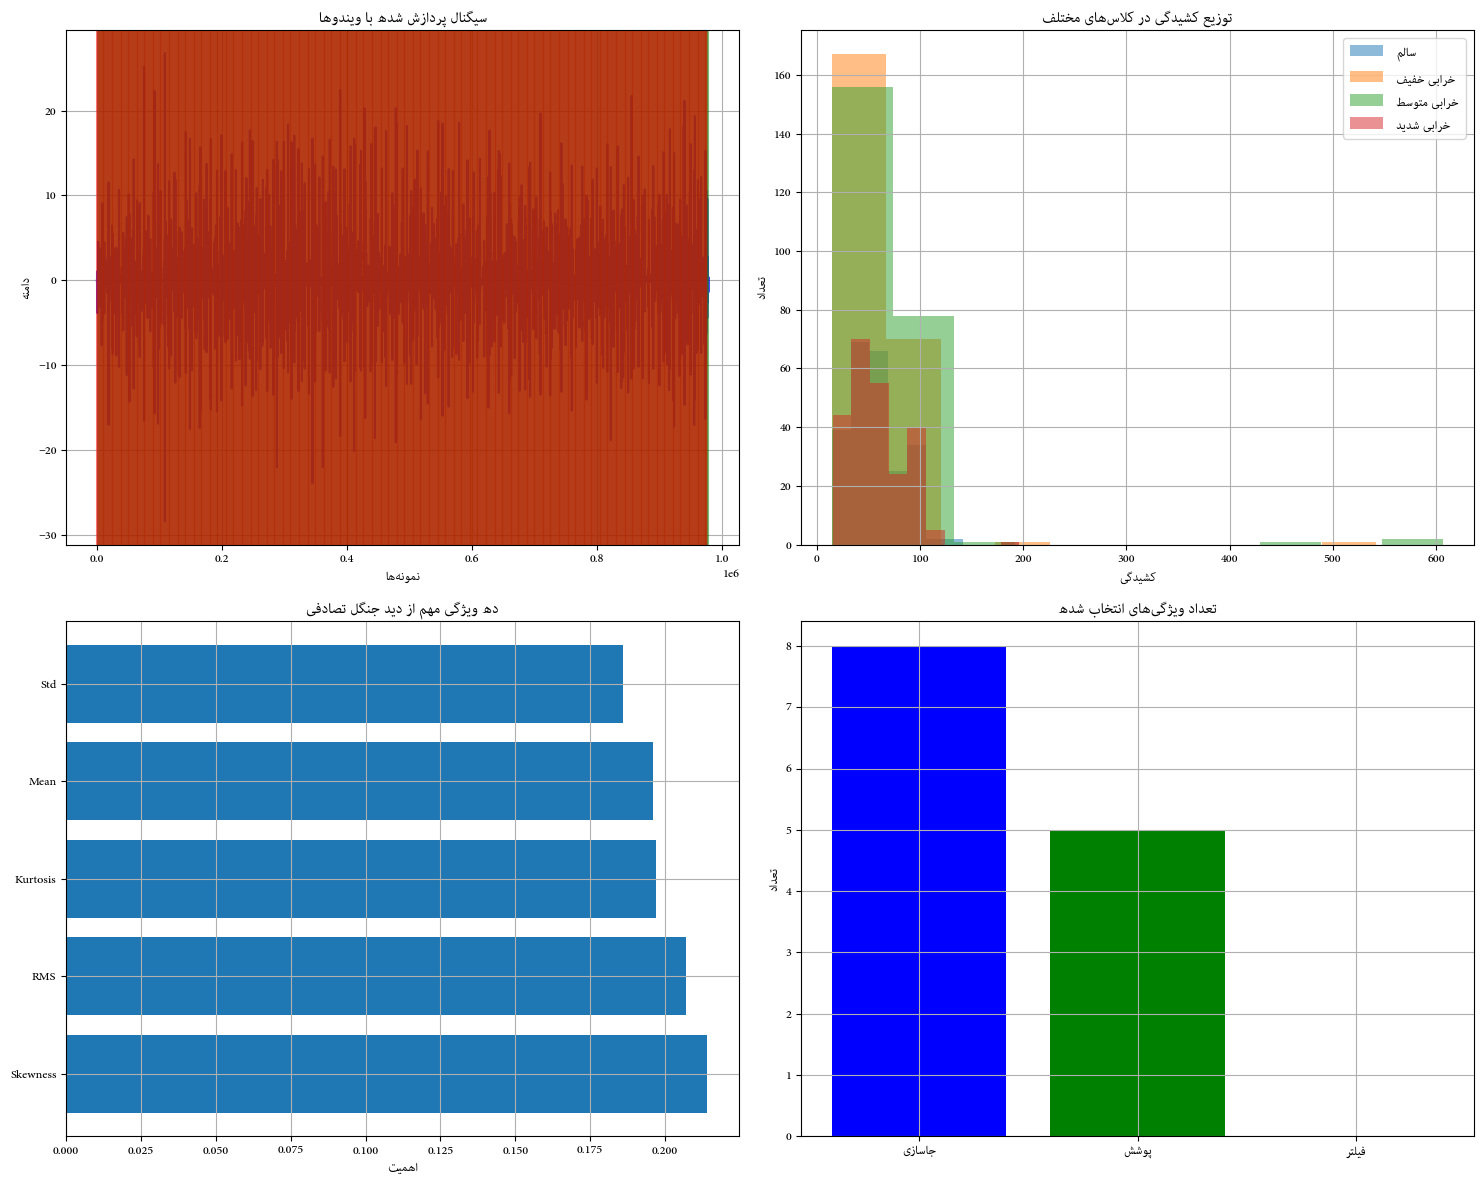

In [29]:
plt.figure(figsize=(15, 12))

# سیگنال اصلی با نشانگر ویندوها
plt.subplot(2, 2, 1)
plt.plot(processed_signal, 'b', alpha=0.7)
for start in valid_starts:
    plt.axvline(start, color='r', alpha=0.3)
    plt.axvline(start + 2048, color='g', alpha=0.3)
plt.title(fa_text('سیگنال پردازش شده با پنجره ها'))
plt.xlabel(fa_text('نمونه‌ها'))
plt.ylabel(fa_text('دامنه'))
plt.grid(True)

# توزیع یک ویژگی مهم
plt.subplot(2, 2, 2)
feature_idx = feature_names.index('Kurtosis')
plt.hist(X[y == 0, feature_idx], alpha=0.5, label=fa_text('سالم'))
plt.hist(X[y == 1, feature_idx], alpha=0.5, label=fa_text('خرابی خفیف'))
plt.hist(X[y == 2, feature_idx], alpha=0.5, label=fa_text('خرابی متوسط'))
plt.hist(X[y == 3, feature_idx], alpha=0.5, label=fa_text('خرابی شدید'))
plt.title(fa_text('توزیع کشیدگی در کلاس‌های مختلف'))
plt.xlabel(fa_text('کشیدگی'))
plt.ylabel(fa_text('تعداد'))
plt.legend()
plt.grid(True)

# اهمیت ویژگی‌ها از دید جنگل تصادفی
plt.subplot(2, 2, 3)
importances = selector_wrapper.estimator_.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:10]  # 10 ویژگی برتر
plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])
plt.title(fa_text('ده ویژگی مهم از دید جنگل تصادفی'))
plt.xlabel(fa_text('اهمیت'))
plt.grid(True)

# مقایسه روش‌های انتخاب ویژگی
plt.subplot(2, 2, 4)
methods = [fa_text('جاسازی'),fa_text('پوشش'),fa_text('فیلتر')]
scores = [
    len(set(selected_filter)),
    len(set(selected_wrapper)),
    len(set(selected_embedded))
]
plt.bar(methods, scores, color=['blue', 'green', 'red'])
plt.title(fa_text('تعداد ویژگی‌های انتخاب شده'))
plt.ylabel(fa_text('تعداد'))
plt.grid(True)

plt.tight_layout()
plt.show()

### 9. ویژگی‌های نهایی ترکیبی

In [30]:
final_features = list(set(selected_filter) | set(selected_wrapper) | set(selected_embedded))
print("\nویژگی‌های اصلی نهایی:")
print([feature_names[i] for i in final_features])


ویژگی‌های اصلی نهایی:
['Mean', 'Skewness', 'Kurtosis', 'RMS', 'Peak', 'Freq_Mean', 'Freq_Peak', 'Freq_Kurtosis', 'Band_0_Energy', 'Band_1_Energy', 'Band_2_Energy']


### 10. آموزش مدل نهایی با ویژگی‌های انتخابی

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# انتخاب ویژگی‌های نهایی
X_final = X[:, final_features]

# تقسیم داده‌ها
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# آموزش مدل
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# ارزیابی مدل
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nدقت مدل نهایی: {accuracy:.2f}")


دقت مدل نهایی: 0.35


### نمایش ماتریس در هم ریختگی
این ماتریس برای ارزیابی عملکرد مدل های طبقه بندی استفاده می شود. این ماتریس پیش بینی های مدل را در مقابل مقادیر واقعی مقایسه می کند. به طورکلی تصویری ارائه می دهد که مدل در کجاها درست یا اشتباه پیش بینی کرده است.

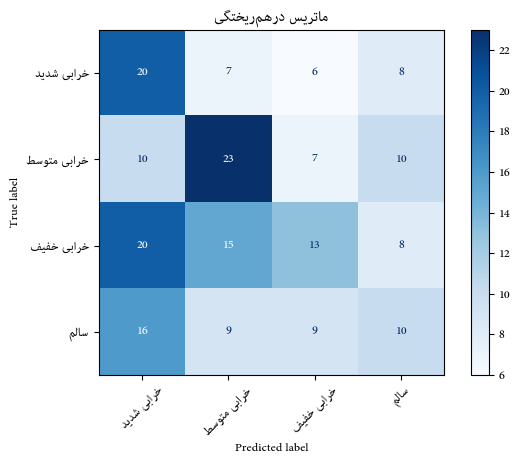

In [32]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=[fa_text('خرابی شدید'),fa_text('خرابی متوسط'),fa_text('خرابی خفیف'),fa_text('سالم')]
)
disp.plot(cmap=plt.cm.Blues)
plt.title(fa_text('ماتریس درهم‌ریختگی'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

در غیاب برچسب‌های واقعی، می‌توانیم از روش‌های بدون ناظر برای برچسب‌گذاری استفاده کنیم. در زمینه تشخیص خرابی گیربکس، معمولاً دو رویکرد اصلی وجود دارد:

1. تشخیص ناهنجاری (Anomaly Detection): 
   - فرض می‌کند که بیشتر داده‌ها مربوط به وضعیت سالم هستند
   - مدل را فقط روی داده‌های سالم آموزش می‌دهیم
   - سپس انحراف از حالت سالم را به عنوان خرابی شناسایی می‌کنیم

2. خوشه‌بندی (Clustering):
   - داده‌ها را به گروه‌های طبیعی تقسیم می‌کنیم
   - فرض می‌کنیم هر خوشه مربوط به یک وضعیت کاری (سالم، خرابی خفیف، خرابی شدید) است

### پیاده‌سازی عملی با استفاده از خوشه‌بندی (K-Means):


تعداد بهینه خوشه‌ها: 2 با امتیاز سیلوئت: 0.47


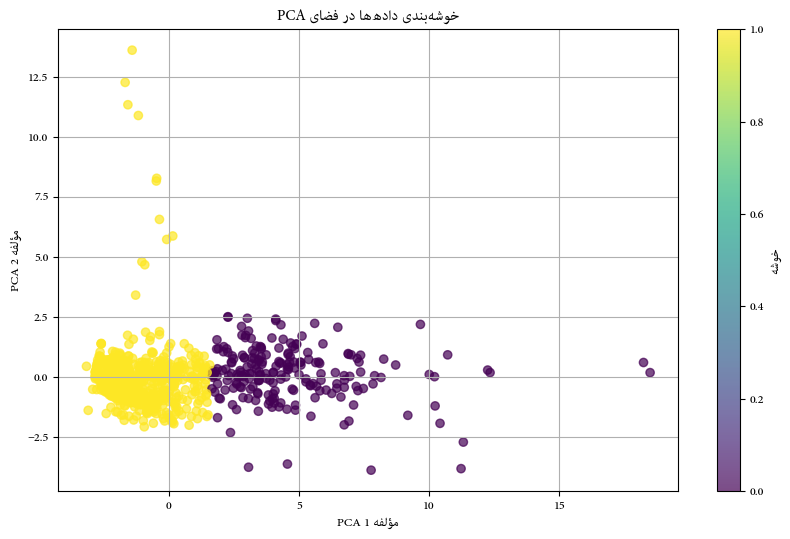

In [34]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. استانداردسازی ویژگی‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. کاهش ابعاد برای مصورسازی (اختیاری)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. تعیین تعداد بهینه خوشه‌ها
k_range = range(2, 6)  # تست 2 تا 5 خوشه
best_k = 2
best_score = -1

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"تعداد بهینه خوشه‌ها: {best_k} با امتیاز سیلوئت: {best_score:.2f}")

# 4. خوشه‌بندی نهایی
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y = final_kmeans.fit_predict(X_scaled)  # y به عنوان برچسب استفاده می‌شود

# 5. مصورسازی خوشه‌ها
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title(fa_text('خوشه‌بندی داده‌ها در فضای PCA'))
plt.xlabel(fa_text('مؤلفه PCA 1'))
plt.ylabel(fa_text('مؤلفه PCA 2'))
plt.colorbar(label=fa_text('خوشه'))
plt.grid(True)
plt.show()

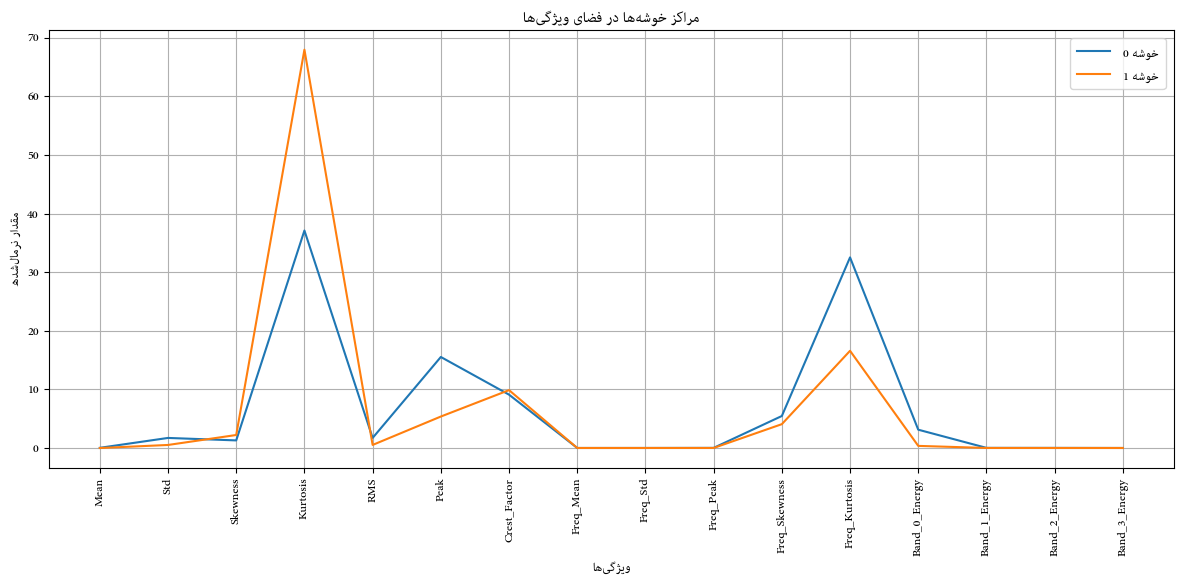

In [36]:
# 6. تحلیل مراکز خوشه‌ها برای تفسیر وضعیت‌ها
cluster_centers = scaler.inverse_transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(12, 6))
for i in range(best_k):
    plt.plot(cluster_centers[i], label=fa_text(f'خوشه {i}'))
    
plt.title(fa_text('مراکز خوشه‌ها در فضای ویژگی‌ها'))
plt.xlabel(fa_text('ویژگی‌ها'))
plt.ylabel(fa_text('مقدار نرمال‌شده'))
plt.legend()
plt.grid(True)
plt.xticks(ticks=range(len(feature_names)), labels=feature_names, rotation=90)
plt.tight_layout()
plt.show()

 معمولاً خوشه‌ای که مقادیر کورتوسیس و انرژی فرکانسی بالاتری دارد، نشان‌دهنده خرابی است

In [38]:
print("\nتفسیر وضعیت خوشه‌ها:")
for i in range(best_k):
    kurtosis_val = cluster_centers[i][feature_names.index('Kurtosis')]
    band_energy = cluster_centers[i][feature_names.index('Band_3_Energy')]
    
    if kurtosis_val > 1.0 and band_energy > np.mean(cluster_centers[:, feature_names.index('Band_3_Energy')]):
        print(f"خوشه {i}: احتمالاً خرابی (کشیدگی = {kurtosis_val:.2f}, انرژی باند بالا = {band_energy:.2f})")
    else:
        print(f"خوشه {i}: احتمالاً سالم (کشیدگی = {kurtosis_val:.2f}, انرژی باند بالا = {band_energy:.2f})")


تفسیر وضعیت خوشه‌ها:
خوشه 0: احتمالاً سالم (کشیدگی = 37.11, انرژی باند بالا = 0.00)
خوشه 1: احتمالاً سالم (کشیدگی = 67.97, انرژی باند بالا = 0.00)


روش خوشه بندی نیازی به دانش فنی ندارد ولی تفسیر نتایج بسیار سخت است. با توجه به نتایج در این مسئله، عملا از این روش نمی توان خرابی ها را برچسب گذاری کرد. پیشنهاد می شود از دانش دامنه برای برچسب گذاری استفاده شود و سپس فرآیند آموزش مدل مورد بهره برداری قرار گیرد.